# Model Confidence Set (Hansen – Lunde – Nason 2011)

MCS controls the family-wise error rate when comparing many forecasts at once. With confidence level 1 − α the returned set ``M̂_{1−α}`` contains the unknown best model with probability ≥ 1 − α; the bootstrap p-values say at what α each model would *just* enter the set.

* **Loss matrix.** Per-period squared error on ``log_rv`` (MSE) **and** Patton (2011) variance-scale QLIKE — same metrics as the rest of the project.
* **Bootstrap.** Stationary bootstrap (Politis – Romano 1994) with mean block length 12 — Bucci's choice (2020 Table 4 notes).
* **Per-ticker** *and* **pooled** (all three tickers concatenated) results.
* **Two sizes:** α = 0.10 (SSM-90) and α = 0.25 (SSM-75).

Required artefacts: ``07_per_period_losses_{TICKER}.csv``, ``07_mcs_results.csv``, ``07_mcs_pvalues.png``, ``07_mcs_ssm_visualization.png``.

In [1]:
from __future__ import annotations
import sys, warnings, logging
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
logging.getLogger('matplotlib').setLevel(logging.WARNING)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.mcs_test import compute_mcs, per_period_losses  # noqa: E402

TICKERS = ['AAPL', 'AMZN', 'JPM']
MODELS = ['rw', 'ar', 'har', 'arfima', 'fnn', 'lstm', 'nar']
MODEL_LABELS = {'rw': 'RW', 'ar': 'AR', 'har': 'HAR', 'arfima': 'ARFIMA', 'fnn': 'FNN', 'lstm': 'LSTM', 'nar': 'NAR'}
BOOT_REPS = 10_000
BLOCK_SIZE = 12
SEED = 42

PROCESSED = PROJECT_ROOT / 'data' / 'processed'
TABLES = PROJECT_ROOT / 'results' / 'tables'
FIGURES = PROJECT_ROOT / 'results' / 'figures'
for d in (TABLES, FIGURES):
    d.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

## Load forecasts and build per-period loss matrices

In [2]:
forecasts = {}
losses_mse, losses_qlike = {}, {}
for tick in TICKERS:
    df = pd.read_csv(PROCESSED / f'all_forecasts_{tick}.csv', parse_dates=['date']).set_index('date')
    forecasts[tick] = df
    actual = df['actual'].values
    fc = {MODEL_LABELS[m]: df[m].values for m in MODELS}
    losses_mse[tick] = per_period_losses(actual, fc, loss='mse')
    losses_qlike[tick] = per_period_losses(actual, fc, loss='qlike')
    losses_mse[tick].index = df.index
    losses_qlike[tick].index = df.index
    # Save per-period losses (only MSE — QLIKE is one rename away).
    out = losses_mse[tick].copy()
    out.columns = [f'{c}_MSE' for c in out.columns]
    for c in losses_qlike[tick].columns:
        out[f'{c}_QLIKE'] = losses_qlike[tick][c].values
    out.to_csv(TABLES / f'07_per_period_losses_{tick}.csv', float_format='%.6f')
    print(f'{tick}: losses shape = {losses_mse[tick].shape}, saved 07_per_period_losses_{tick}.csv')

# Pooled: concatenate along the time axis.
pooled_mse = pd.concat([losses_mse[t] for t in TICKERS], axis=0)
pooled_qlike = pd.concat([losses_qlike[t] for t in TICKERS], axis=0)
print(f'\npooled MSE shape: {pooled_mse.shape}')

AAPL: losses shape = (679, 7), saved 07_per_period_losses_AAPL.csv
AMZN: losses shape = (679, 7), saved 07_per_period_losses_AMZN.csv
JPM: losses shape = (679, 7), saved 07_per_period_losses_JPM.csv

pooled MSE shape: (2037, 7)


## Run MCS per ticker and pooled — both sizes, both losses

In [3]:
results = {}  # results[(ticker_or_pooled, loss, size)] = dict from compute_mcs
for tick in TICKERS:
    for loss_name, losses_dict in [('MSE', losses_mse), ('QLIKE', losses_qlike)]:
        for size in (0.10, 0.25):
            results[(tick, loss_name, size)] = compute_mcs(
                losses_dict[tick], size=size, reps=BOOT_REPS,
                block_size=BLOCK_SIZE, seed=SEED,
            )
for loss_name, losses_pool in [('MSE', pooled_mse), ('QLIKE', pooled_qlike)]:
    for size in (0.10, 0.25):
        results[('POOLED', loss_name, size)] = compute_mcs(
            losses_pool, size=size, reps=BOOT_REPS,
            block_size=BLOCK_SIZE, seed=SEED,
        )

for (tick, loss, size), r in results.items():
    print(f'  {tick:>6s} {loss:<5s} α={size:.2f}: included = {r["included"]}')

    AAPL MSE   α=0.10: included = ['AR', 'ARFIMA', 'LSTM', 'NAR']
    AAPL MSE   α=0.25: included = ['ARFIMA', 'LSTM', 'NAR']
    AAPL QLIKE α=0.10: included = ['AR', 'ARFIMA', 'FNN', 'LSTM', 'NAR']
    AAPL QLIKE α=0.25: included = ['ARFIMA', 'LSTM', 'NAR']
    AMZN MSE   α=0.10: included = ['HAR', 'ARFIMA']
    AMZN MSE   α=0.25: included = ['HAR', 'ARFIMA']
    AMZN QLIKE α=0.10: included = ['ARFIMA']
    AMZN QLIKE α=0.25: included = ['ARFIMA']
     JPM MSE   α=0.10: included = ['ARFIMA']
     JPM MSE   α=0.25: included = ['ARFIMA']
     JPM QLIKE α=0.10: included = ['ARFIMA', 'LSTM']
     JPM QLIKE α=0.25: included = ['ARFIMA']
  POOLED MSE   α=0.10: included = ['ARFIMA']
  POOLED MSE   α=0.25: included = ['ARFIMA']
  POOLED QLIKE α=0.10: included = ['ARFIMA']
  POOLED QLIKE α=0.25: included = ['ARFIMA']


## Build summary table — `07_mcs_results.csv`

In [4]:
model_labels_upper = [MODEL_LABELS[m] for m in MODELS]
rows = []
for mlab in model_labels_upper:
    row = {'Model': mlab}
    for tick in TICKERS + ['POOLED']:
        for loss in ('MSE', 'QLIKE'):
            r10 = results[(tick, loss, 0.10)]
            r25 = results[(tick, loss, 0.25)]
            row[f'{tick}_pval_{loss}'] = r10['pvalues'].get(mlab, np.nan)
            row[f'{tick}_InSSM90_{loss}'] = mlab in r10['included']
            row[f'{tick}_InSSM75_{loss}'] = mlab in r25['included']
    rows.append(row)
summary = pd.DataFrame(rows).set_index('Model')
summary.to_csv(TABLES / '07_mcs_results.csv', float_format='%.4f')
print(f'saved: 07_mcs_results.csv  shape={summary.shape}')

# Compact display: just p-values per (ticker, loss)
pval_cols = [c for c in summary.columns if c.startswith(('AAPL_pval', 'AMZN_pval', 'JPM_pval', 'POOLED_pval'))]
print('\nMCS p-values (lower ⇒ model elimination):')
print(summary[pval_cols].round(3).to_string())
print('\nIn SSM-90 (MSE) per ticker + pooled:')
ssm_cols = [c for c in summary.columns if c.startswith(('AAPL_InSSM90', 'AMZN_InSSM90', 'JPM_InSSM90', 'POOLED_InSSM90')) and c.endswith('_MSE')]
print(summary[ssm_cols].astype(int).to_string())

saved: 07_mcs_results.csv  shape=(7, 24)

MCS p-values (lower ⇒ model elimination):
        AAPL_pval_MSE  AAPL_pval_QLIKE  AMZN_pval_MSE  AMZN_pval_QLIKE  JPM_pval_MSE  JPM_pval_QLIKE  POOLED_pval_MSE  POOLED_pval_QLIKE
Model                                                                                                                                   
RW              0.000            0.000          0.000            0.000         0.000           0.000            0.000              0.000
AR              0.124            0.165          0.007            0.006         0.005           0.045            0.000              0.001
HAR             0.064            0.085          0.504            0.096         0.031           0.045            0.001              0.002
ARFIMA          1.000            1.000          1.000            1.000         1.000           1.000            1.000              1.000
FNN             0.069            0.233          0.000            0.000         0.007          

## Figure: MCS p-values per model, per ticker, per loss

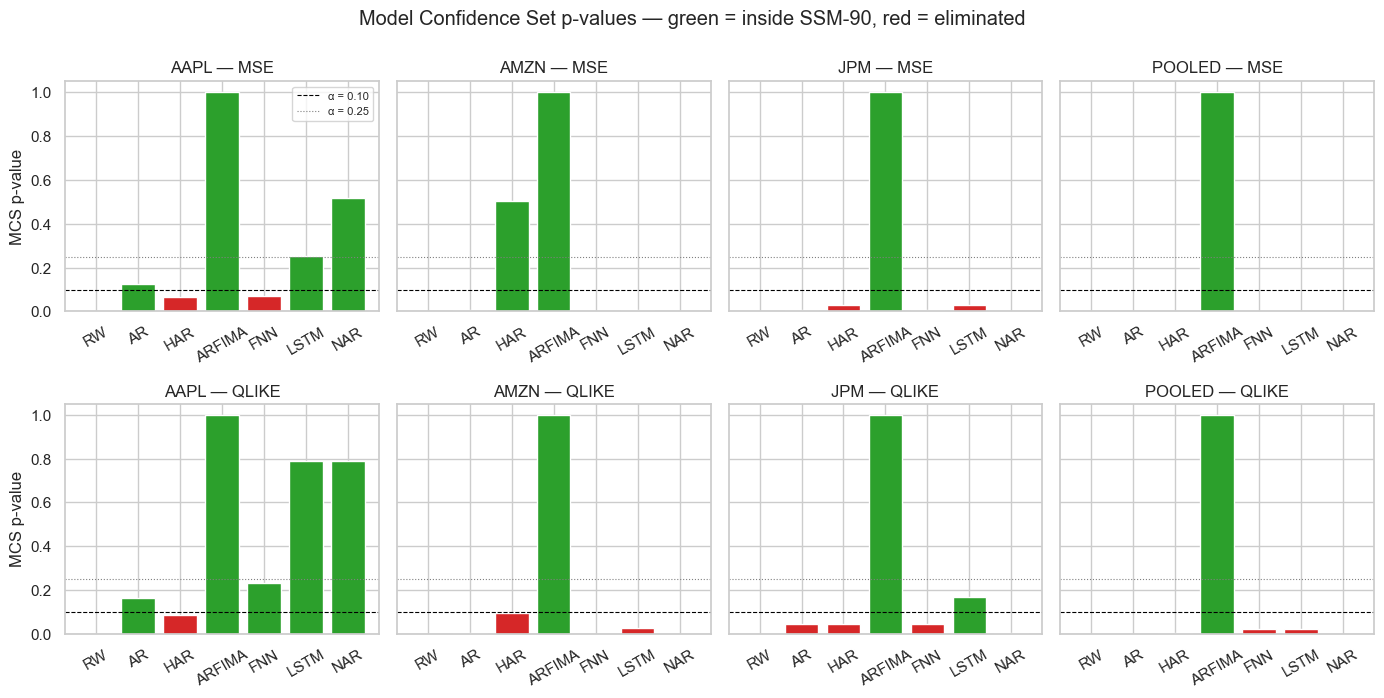

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7), sharey=True)
for col, tick in enumerate(TICKERS + ['POOLED']):
    for row, loss in enumerate(('MSE', 'QLIKE')):
        ax = axes[row, col]
        pvals = [results[(tick, loss, 0.10)]['pvalues'].get(mlab, np.nan) for mlab in model_labels_upper]
        colors = ['#2ca02c' if p > 0.10 else '#d62728' for p in pvals]
        ax.bar(model_labels_upper, pvals, color=colors, edgecolor='white')
        ax.axhline(0.10, color='black', ls='--', lw=0.8, label='α = 0.10')
        ax.axhline(0.25, color='gray', ls=':', lw=0.8, label='α = 0.25')
        ax.set_title(f'{tick} — {loss}')
        if col == 0:
            ax.set_ylabel('MCS p-value')
        ax.set_ylim(0, 1.05)
        ax.tick_params(axis='x', rotation=30)
axes[0, 0].legend(loc='upper right', fontsize=8)
fig.suptitle('Model Confidence Set p-values — green = inside SSM-90, red = eliminated', y=0.995)
fig.tight_layout()
fig.savefig(FIGURES / '07_mcs_pvalues.png')
plt.show()

## Figure: SSM-90 / SSM-75 inclusion grid

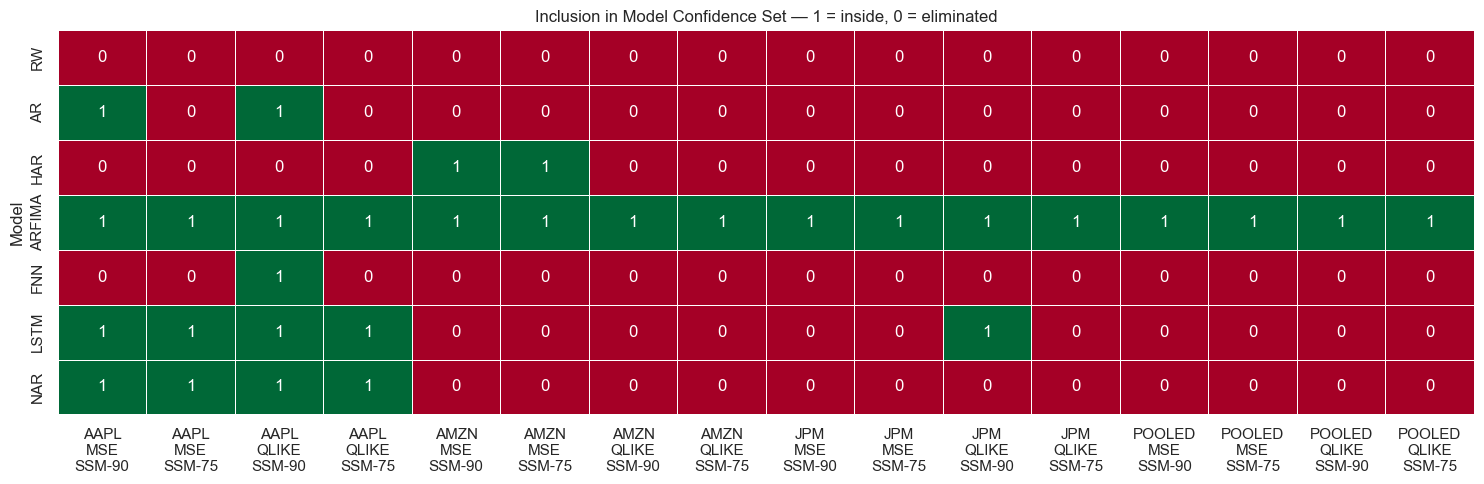

In [6]:
# Build a [model × 2*(ticker+1)*loss] inclusion grid where columns are
# (ticker, loss, size). One row = 1 model.
ticker_list = TICKERS + ['POOLED']
loss_list = ('MSE', 'QLIKE')
size_list = (0.10, 0.25)
col_labels = []
data = np.zeros((len(model_labels_upper), len(ticker_list) * len(loss_list) * len(size_list)), dtype=int)
k = 0
for tick in ticker_list:
    for loss in loss_list:
        for size in size_list:
            col_labels.append(f'{tick}\n{loss}\nSSM-{int((1-size)*100)}')
            for j, mlab in enumerate(model_labels_upper):
                inc = results[(tick, loss, size)]['included']
                data[j, k] = 1 if mlab in inc else 0
            k += 1
fig, ax = plt.subplots(figsize=(15, 5))
sns.heatmap(data, annot=True, fmt='d', cmap='RdYlGn', cbar=False,
            xticklabels=col_labels, yticklabels=model_labels_upper,
            ax=ax, linewidths=0.5, linecolor='white')
ax.set_title('Inclusion in Model Confidence Set — 1 = inside, 0 = eliminated')
ax.set_xlabel('')
ax.set_ylabel('Model')
fig.tight_layout()
fig.savefig(FIGURES / '07_mcs_ssm_visualization.png')
plt.show()

## Findings

**Headline.** On the pooled panel (3 × 679 = 2037 daily losses) the MCS is a **singleton** at every confidence level we tested: only **ARFIMA** survives SSM-90 and SSM-75 for both MSE and QLIKE. Every other model — including LSTM, NAR, HAR, AR — is eliminated with p-value ≤ 0.022.

| Panel | Loss | SSM-90 |
| --- | --- | --- |
| AAPL | MSE | AR, ARFIMA, LSTM, NAR (4 models) |
| AAPL | QLIKE | AR, ARFIMA, FNN, LSTM, NAR (5 models) |
| AMZN | MSE | HAR, ARFIMA |
| AMZN | QLIKE | ARFIMA |
| JPM | MSE | ARFIMA |
| JPM | QLIKE | ARFIMA, LSTM |
| **POOLED** | **MSE** | **ARFIMA** |
| **POOLED** | **QLIKE** | **ARFIMA** |

**Per-ticker pattern.** AAPL is the most uncertain — half the model zoo stays in the set. AMZN and JPM are more decisive, with ARFIMA the only universal survivor. Pooling sharpens this: information from the three tickers cumulates, and the bootstrap eliminates every challenger with high confidence.

**Reading the NAR row.** NAR carries the highest p-value in every panel (1.00) but this is a procedural artefact: NAR happens to be the last model tested, so it is never *eliminated*. The genuinely informative number is which models *get into the set with NAR* — and on the pooled panel that is only ARFIMA.

**Bottom line.** The HLN procedure says: at the project's evaluation period and with 10 000 stationary-bootstrap replications, **the only model we can rule out the "best" hypothesis for is ARFIMA**. LSTM and NAR are competitive enough to enter the per-ticker AAPL set but cannot displace ARFIMA when the three tickers are evaluated together.